# Adaptive Audio Augmentation Functions

This notebook demonstrates the `adaptive_random_gain` and `adaptive_random_noise` functions from `opensoundscape.preprocess.action_functions`.

These functions adapt their behavior based on the input audio level, making them more robust for training models on audio with varying loudness.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from opensoundscape import Audio, Spectrogram
from opensoundscape.preprocess.action_functions import (
    adaptive_random_gain,
    adaptive_random_noise,
)
import opensoundscape

# Load example audio
audio = opensoundscape.birds

## 1. Adaptive Random Gain

The `adaptive_random_gain` function applies random gain while ensuring the output doesn't fall below a minimum dBFS level.

### Original Audio

Original audio dBFS: -42.99


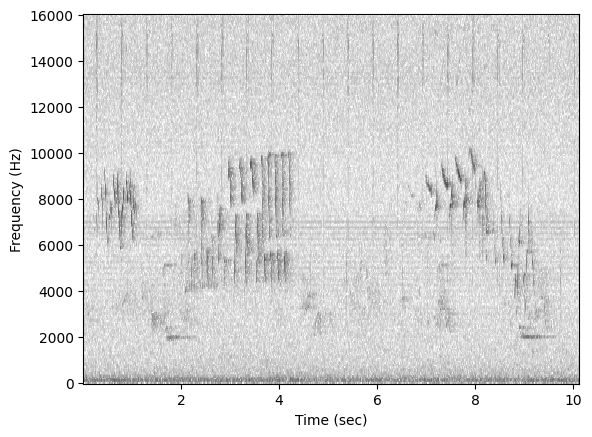

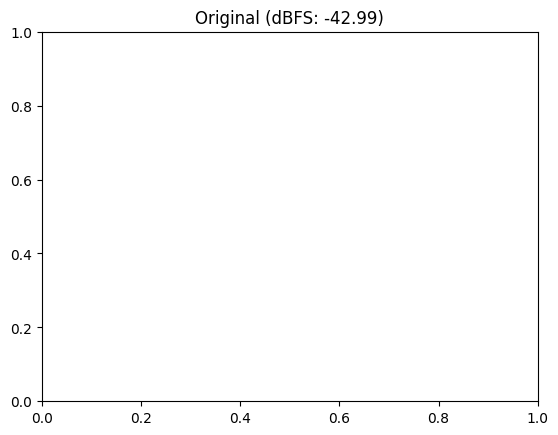

In [3]:
print(f"Original audio dBFS: {audio.dBFS:.2f}")
Spectrogram.from_audio(audio).plot()
plt.title(f"Original (dBFS: {audio.dBFS:.2f})")
plt.show()

### Multiple Stochastic Outputs

Let's apply `adaptive_random_gain` multiple times to see the random variation:

In [ ]:
print(f"input level: {audio.dBFS:.2f} dBFS")
for i in range(6):
    # Apply adaptive random gain with range -30 to 0 dB and minimum output level of -40 dBFS
    result = adaptive_random_gain(audio, gain_range=(-30, 0), min_output_level=-50)

    print(f"Output {i+1} (dBFS: {result.dBFS:.2f})")

input level: -42.99 dBFS
Output 1 (dBFS: -48.72)
Output 2 (dBFS: -48.50)
Output 3 (dBFS: -48.00)
Output 4 (dBFS: -45.81)
Output 5 (dBFS: -47.14)
Output 6 (dBFS: -43.43)


In [ ]:
print(f"input level: {audio.dBFS:.2f} dBFS")
for i in range(6):
    # Apply adaptive random gain with range -30 to 0 dB and minimum output level of -40 dBFS
    result = adaptive_random_gain(audio, gain_range=(-30, 0), min_output_level=-30)

    print(f"Output {i+1} (dBFS: {result.dBFS:.2f})")

input level: -42.99 dBFS
Output 1 (dBFS: -33.78)
Output 2 (dBFS: -38.93)
Output 3 (dBFS: -39.77)
Output 4 (dBFS: -32.29)
Output 5 (dBFS: -39.29)
Output 6 (dBFS: -31.27)


In [ ]:
norm = audio.normalize()
print(f"input level: {norm.dBFS:.2f} dBFS")
for i in range(6):
    # Apply adaptive random gain with range -30 to 0 dB and minimum output level of -40 dBFS
    result = adaptive_random_gain(norm, gain_range=(-30, 0), min_output_level=-20)
    print(f"Output {i+1} (dBFS: {result.dBFS:.2f})")

input level: -13.57 dBFS
Output 1 (dBFS: -19.66)
Output 2 (dBFS: -19.85)
Output 3 (dBFS: -17.56)
Output 4 (dBFS: -17.05)
Output 5 (dBFS: -15.95)
Output 6 (dBFS: -18.15)


## 2. Adaptive Random Noise

The `adaptive_random_noise` function adds noise at a level that adapts to the input signal level, using a specified signal-to-noise ratio (SNR) range.

### Multiple Stochastic Outputs with Original Audio

input level: -42.99 dBFS
Output 1 (dBFS: -42.77, 0.22 dB added noise)


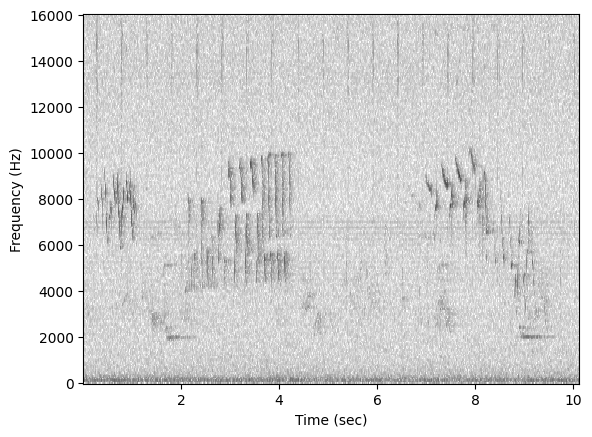

Output 2 (dBFS: -42.98, 0.01 dB added noise)


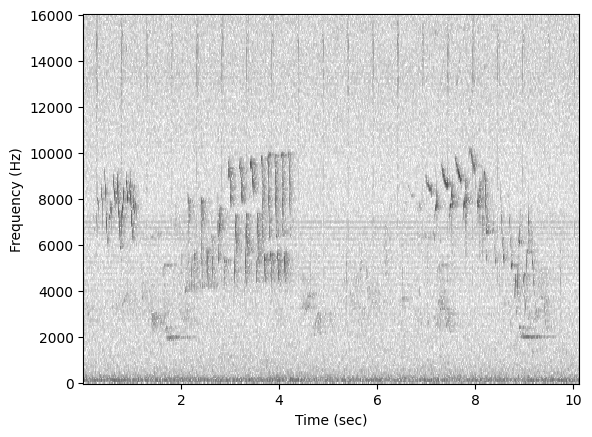

Output 3 (dBFS: -33.58, 9.41 dB added noise)


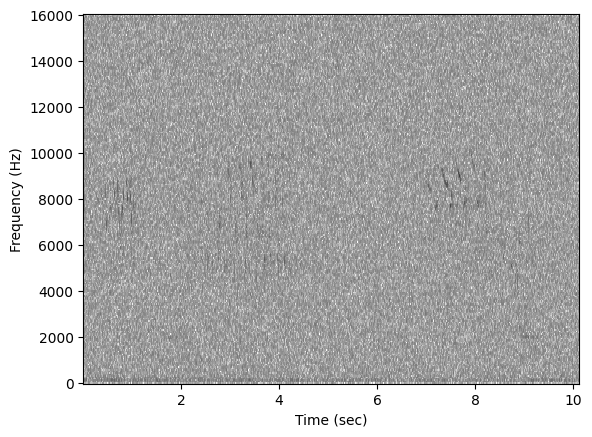

Output 4 (dBFS: -42.44, 0.55 dB added noise)


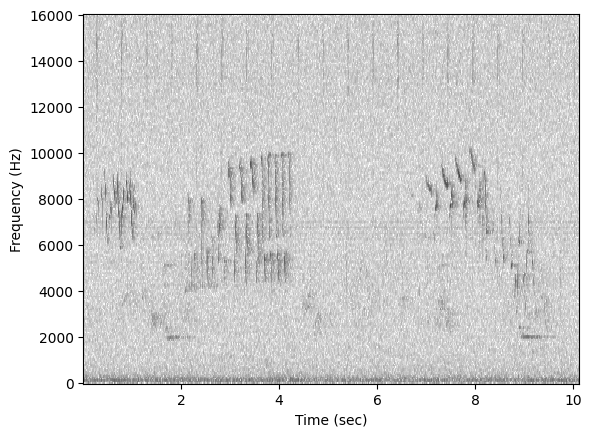

Output 5 (dBFS: -42.98, 0.01 dB added noise)


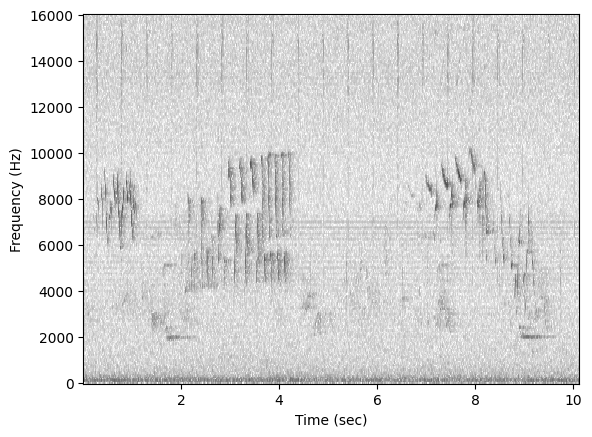

Output 6 (dBFS: -41.47, 1.52 dB added noise)


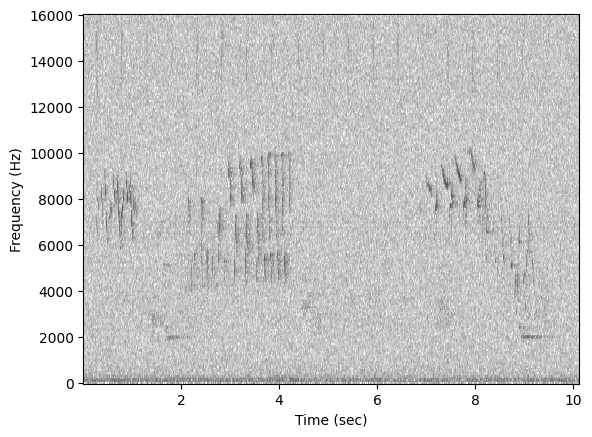

In [ ]:
print(f"input level: {audio.dBFS:.2f} dBFS")
for i in range(6):
    # Apply adaptive random gain with range -30 to 0 dB and minimum output level of -40 dBFS
    result = adaptive_random_noise(audio, snr_range=(-30, 10), signal_dB=0)

    print(
        f"Output {i+1} (dBFS: {result.dBFS:.2f}, {result.dBFS-audio.dBFS:.2f} dB added noise)"
    )
    Spectrogram.from_audio(result).plot()

### Comparing Different Noise Colors


Noise color: white


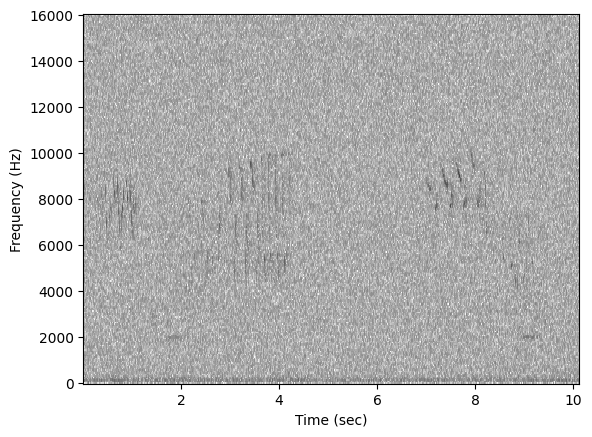


Noise color: pink


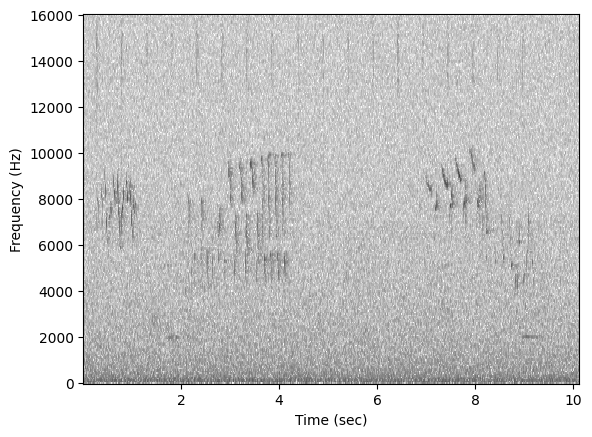


Noise color: brown


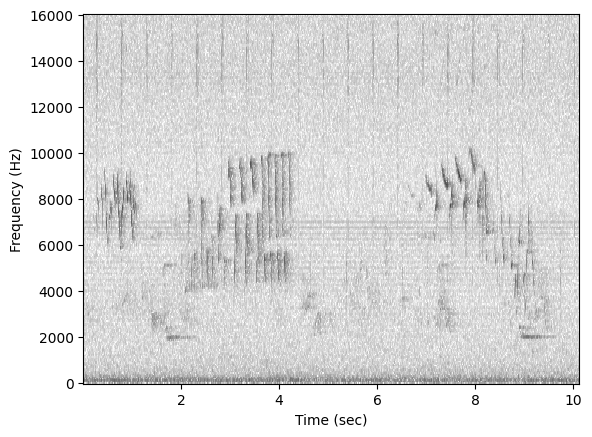

In [ ]:
noise_colors = ["white", "pink", "brown"]

for i, color in enumerate(noise_colors):
    # Apply adaptive random noise with specified color
    print(f"\nNoise color: {color}")
    result = adaptive_random_noise(audio, snr_range=(5, 5), signal_dB=0, color=color)

    # Plot spectrogram
    Spectrogram.from_audio(result).plot()